# Worksheet-5 Solution
## Implementation of Convolutional Neural Network using Keras

**Module:** Artificial Intelligence and Machine Learning  
**Institution:** Herald College Kathmandu  
**Submitted Date:** April 06, 2026

---

### Student Details

| Name | ID Number | Group |
| :--- | :--- | :--- |
| **Narayan Lohani** | 2408869 | L6CG15 |

---

<div style="display: flex; justify-content: space-between; align-items: center; border: none;">
  <img src="https://heraldcollege.edu.np/images/footer/footer-logo-dark.svg" width="180" alt="Herald College Logo">
  <img src="
  https://bizzeducation.com/storage/university-partners/May2024/r3iG0n8CHfh1nCAIz5BO.png" width="180" alt="University of Wolverhampton Logo">
</div>


## 7 Exercise

Implement an End to End CNN Model for Image Classification Task.

### Objective

In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.


In [ ]:
import tensorflow as tf
import keras
import numpy as np

# Verify TensorFlow is correctly installed and display its version
print(f"✅ TensorFlow version: {tf.__version__}")


✅ TensorFlow version: 2.21.0


## Task 1: Data Understanding and Visualization:

Download the Provided Data and Complete the following task.

### **1.  Load and visualize images:**

from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:

-   Get the list of class directories from the train folder.

-   Select one image randomly from each class.

-   Display the images in a grid format with two rows using `matplotlib`.

-   **What did you Observe?**

In [ ]:
# Set the directory paths for training and testing data
TRAIN_DIR = "FruitinAmazon/train/"
TEST_DIR = "FruitinAmazon/test/"

print("Train dir:", TRAIN_DIR)
print("Test  dir:", TEST_DIR)


Train dir: FruitinAmazon/train/
Test  dir: FruitinAmazon/test/


In [ ]:
import os

# Get sorted list of class directories from the train folder
class_names = sorted(
    [
        directory
        for directory in os.listdir(TRAIN_DIR)
        if os.path.isdir(os.path.join(TRAIN_DIR, directory))
    ]
)

num_classes = len(class_names)
print(f"Total number of classes found: {num_classes}")

print("Classes names:", class_names)


Total number of classes found: 6
Classes names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_images = {}
class_counts = {}

for fruit_class in class_names:
    class_path = os.path.join(TRAIN_DIR, fruit_class)

    images = [
        image_file
        for image_file in os.listdir(class_path)
        if image_file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Store the count for this class
    class_counts[fruit_class] = len(images)

    if images:
        sample_images[fruit_class] = os.path.join(class_path, random.choice(images))

# Print the total number of samples in each class
print("----- Class Distribution in Train directory -----")
for fruit_class, count in class_counts.items():
    print(f"{fruit_class}: {count} images")
print("-------------------------")
print(f"Total images: {sum(class_counts.values())}")
print("-------------------------")


----- Class Distribution in Train directory -----
acai: 15 images
cupuacu: 15 images
graviola: 15 images
guarana: 15 images
pupunha: 15 images
tucuma: 15 images
-------------------------
Total images: 90
-------------------------


In [ ]:
from PIL import Image

# Printing Metadata for one Random Sample Image
if sample_images:
    random_class = random.choice(list(sample_images.keys()))
    sample_path = sample_images[random_class]

    with Image.open(sample_path) as img_meta:
        print(f"----- Metadata for Sample: {os.path.basename(sample_path)} -----")
        print(f"Class: {random_class}")
        print(f"Format: {img_meta.format}")
        print(f"Mode: {img_meta.mode}")
        print(f"Size (Width x Height): {img_meta.size}")
        print("-" * 40)


----- Metadata for Sample: images (7).jpeg -----
Class: guarana
Format: JPEG
Mode: RGB
Size (Width x Height): (275, 183)
----------------------------------------


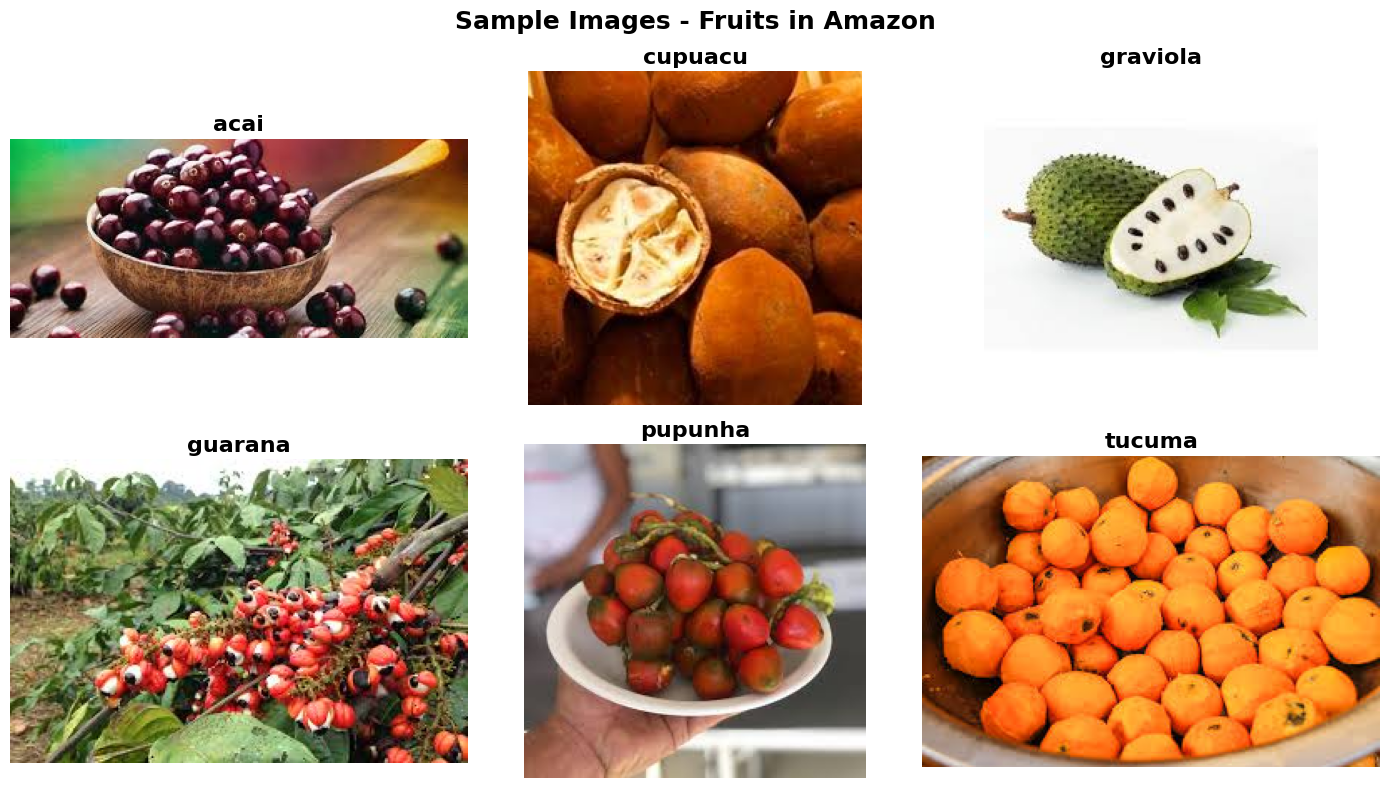

In [ ]:
# Display a sample image of each fruit in a 2-row grid (3 images per row)
cols, rows = 3, 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 8))
axes = axes.flatten()

# Select one random image per class
for idx, (image_class, img_path) in enumerate(sample_images.items()):
    img = mpimg.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(image_class, fontsize=16, fontweight="bold")
    axes[idx].axis("off")

plt.suptitle("Sample Images - Fruits in Amazon", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()


**Observation**

* The dataset 6 classes of Amazonian fruits: acai, cupuacu, graviola, guarana, pupunha, tucuma

* There are only 15 images per class, which is very few for training, meaning the model can be at the risk of overfitting.
---

### **2. Check for Corrupted Image:** 

Write a script that verifies whether the image in the train directory are valid. If any corrupted images are found, the script must remove the image from the directory and print the message which image have been removed, if none found print "No Corrupted Images Found."

-   **Hint:**

    -   Iterate through each class subdirectory and check if each image is valid.

    -   Use the `Image.open()` function to attempt to load each image.

    -   If the image is corrupted i.e. raises an `IOError` or `SyntaxError`, remove the image from the directory and `print(f"Removed corrupted image: {image_path})"`.

    -   Maintain a list of all corrupted image paths for reporting.

-   **Expected Output:** No corrupted images found.

In [ ]:
corrupted = []

for fruit_class in class_names:
    fruit_class_path = os.path.join(TRAIN_DIR, fruit_class)
    for fname in os.listdir(fruit_class_path):
        img_path = os.path.join(fruit_class_path, fname)
        try:
            with Image.open(img_path) as img:
                img.verify()  # verify integrity
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if not corrupted:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted)}")


No Corrupted Images Found.


---

### Task 2: Loading and Preprocessing Image Data in keras:

In [ ]:
from keras.layers import Rescaling
from keras.preprocessing import image_dataset_from_directory

# Hyper-parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
SEED = 123

# Normalisation layer, scales pixel values to [0, 1]
rescale = Rescaling(1.0 / 255)

# Training Dataset
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation Dataset
val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test Dataset
test_ds = image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


### Task 3 - Implement a CNN with

Follow the following Structure and Hyper - parameters:

**Convolutional Architecture:**

-   **Convolutional Layer 1:**

    -   Filter Size (F): (3, 3)

    -   Number of Filters (k): 32

    -   Padding (P): same

    -   Stride (s): 1

-   **Activation Layer:** ReLU activation

-   **Pooling Layer 1:** Max pooling

    -   Filter Size (F): (2, 2)

    -   Stride (s): 2

-   **Convolutional Layer 2:**

    -   Filter Size (F): (3, 3)

    -   Number of Filters (k): 32

    -   Padding (P): same

    -   Stride (s): 1

-   **Activation Layer:** ReLU activation

-   **Pooling Layer 2:** Max pooling

    -   Filter Size (F): (2, 2)

    -   Stride (s): 2

**Fully Connected Network Architecture:**

-   **Flatten Layer:** Flatten the input coming from the convolutional layers

-   **Input Layer:**

-   **Hidden Layer - 2:**

    -   Number of Neurons: 64

    -   Number of Neurons: 128

-   **Output Layer:**

    -   Number of Neurons: num classes (number of output classes)

In [ ]:
from keras import Sequential
from keras.layers import Input, Conv2D, Flatten, Dense, MaxPooling2D

model = Sequential(
    [
        Input(
            shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        ),
    ],
    name="FruitsInAmazon_CNN",
)

# Convolutional Block 1
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding="same",
        activation="relu",
        name="conv2d_1",
    ),
)

# First pooling layer
model.add(
    MaxPooling2D(pool_size=(2, 2), strides=2, name="maxpool_1"),
)

# Convolutional Block 2
model.add(
    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding="same",
        activation="relu",
        name="conv2d_2",
    ),
)

# Second pooling layer
model.add(
    MaxPooling2D(pool_size=(2, 2), strides=2, name="maxpool_2"),
)

# Flatten the nodes
model.add(Flatten(name="flatten"))

# Fully Connected layer 1
model.add(Dense(128, activation="relu", name="dense_128"))
# Fully Connected layer 1
model.add(Dense(64, activation="relu", name="dense_64"))
# Output (Softmax) layer
model.add(Dense(num_classes, activation="softmax", name="output"))


model.summary()


Model: "FruitsInAmazon_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

### Task 4: Compile the Model

**Model Compilation**

-   Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy).

In [ ]:
# Compile the model with optimizer, loss function and metrics
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
print("Model Compiled Successfully!")


Model Compiled Successfully!


### Task 5: Train the Model

**Model Training**

-   Use the `model.fit()` function to train the model. Set the batch size to 16 and the number of epochs to 250.

-   Use `val ds` for validation.

-   Use callbacks such as `ModelCheckpoint` and `EarlyStopping` for saving the best model and avoiding overfitting.

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

EPOCHES = 250

# Callback to model with highest accuracy
checkpoint_cb = ModelCheckpoint(
    filepath="callback_accuracy.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

# Callback to model when loss stops decreasing
early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1,
)

# Train the model wiht all configurations
history = model.fit(
    train_ds,
    epochs=EPOCHES,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
)


Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1292 - loss: 3.2138
Epoch 1: val_accuracy improved from None to 0.00000, saving model to callback_accuracy.h5



Epoch 1: finished saving model to callback_accuracy.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.1250 - loss: 3.2720 - val_accuracy: 0.0000e+00 - val_loss: 1.7532
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1833 - loss: 1.8070
Epoch 2: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2083 - loss: 1.8044 - val_accuracy: 0.0000e+00 - val_loss: 1.8213
Epoch 3/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.2891 - loss: 1.6740
Epoch 3: val_accuracy improved from 0.00000 to 0.38889, saving model to callback_accuracy.h5



Epoch 3: finished saving model to callback_accuracy.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.2778 - loss: 1.6505 - val_accuracy: 0.3889 - val_loss: 1.6485
Epoch 4/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3789 - loss: 1.5679
Epoch 4: val_accuracy improved from 0.38889 to 0.50000, saving model to callback_accuracy.h5



Epoch 4: finished saving model to callback_accuracy.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4167 - loss: 1.5242 - val_accuracy: 0.5000 - val_loss: 1.5222
Epoch 5/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8190 - loss: 1.2548
Epoch 5: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7361 - loss: 1.2447 - val_accuracy: 0.5000 - val_loss: 1.3716
Epoch 6/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7878 - loss: 1.0212
Epoch 6: val_accuracy did not improve from 0.50000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.7778 - loss: 0.9613 - val_accuracy: 0.4444 - val_loss: 1.1261
Epoch 7/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8346 - loss: 0.6583
Epoch 7: val_accuracy improved from 0.50000 to 0.72222, saving model to callback_accuracy.h5



Epoch 7: finished saving model to callback_accuracy.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7778 - loss: 0.7378 - val_accuracy: 0.7222 - val_loss: 0.7976
Epoch 8/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9089 - loss: 0.4639
Epoch 8: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9306 - loss: 0.4549 - val_accuracy: 0.6111 - val_loss: 0.7249
Epoch 9/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9427 - loss: 0.2249
Epoch 9: val_accuracy improved from 0.72222 to 0.83333, saving model to callback_accuracy.h5



Epoch 9: finished saving model to callback_accuracy.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9444 - loss: 0.2474 - val_accuracy: 0.8333 - val_loss: 0.4300
Epoch 10/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9779 - loss: 0.1292
Epoch 10: val_accuracy improved from 0.83333 to 0.88889, saving model to callback_accuracy.h5



Epoch 10: finished saving model to callback_accuracy.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9583 - loss: 0.1578 - val_accuracy: 0.8889 - val_loss: 0.3634
Epoch 11/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9909 - loss: 0.0956
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9861 - loss: 0.0943 - val_accuracy: 0.8333 - val_loss: 0.6502
Epoch 12/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9674 - loss: 0.0958
Epoch 12: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9861 - loss: 0.0638 - val_accuracy: 0.8333 - val_loss: 0.3735
Epoch 13/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 1.0000 - loss: 0.0333
Epoch 13: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.0358 - val_accuracy: 0.8333 - val_loss: 0.4236
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss


Epoch 16: finished saving model to callback_accuracy.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.9444 - val_loss: 0.2986
Epoch 17/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 1.0000 - loss: 0.0090
Epoch 17: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 0.8333 - val_loss: 0.2573
Epoch 18/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.0045
Epoch 18: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.8333 - val_loss: 0.5691
Epoch 19/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 0.0041
Epoch 19: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.8333 - val_loss: 0.6064
Epoch 20/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss

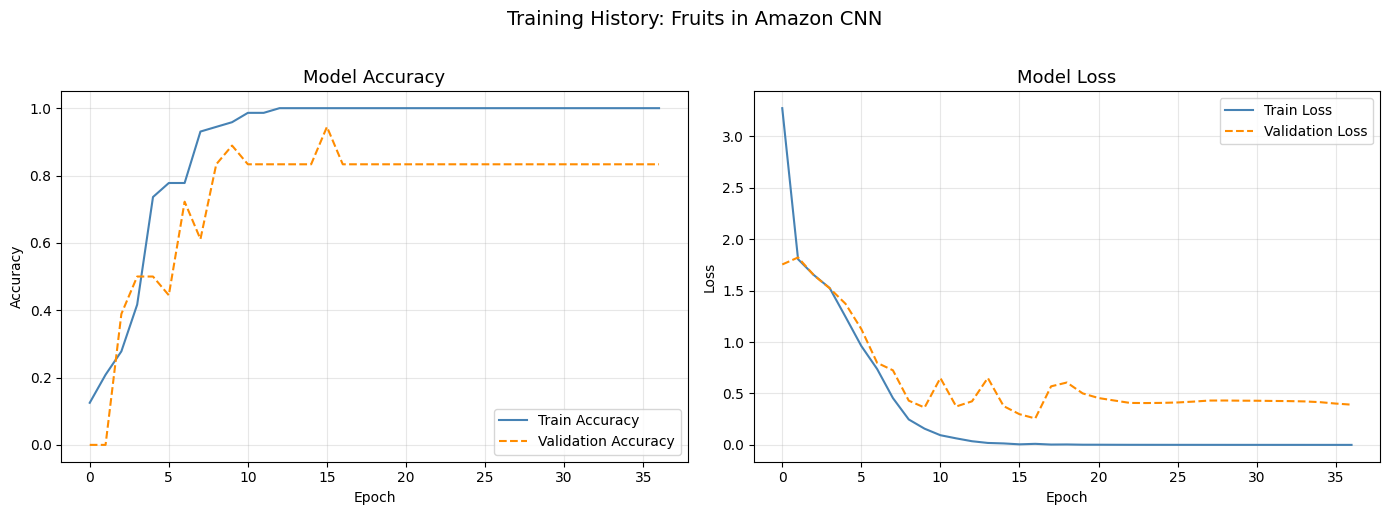

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history["accuracy"], label="Train Accuracy", color="steelblue")
ax1.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    color="darkorange",
    linestyle="--",
)
ax1.set_title("Model Accuracy", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history["loss"], label="Train Loss", color="steelblue")
ax2.plot(
    history.history["val_loss"],
    label="Validation Loss",
    color="darkorange",
    linestyle="--",
)
ax2.set_title("Model Loss", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Training History: Fruits in Amazon CNN", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Task 6: Evaluate the Model

**Model Evaluation**

-   After training, evaluate the model using `model.evaluate()` on the test set to check the test accuracy and loss.

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7333 - loss: 0.8494

Test Loss     : 0.8494
Test Accuracy : 0.7333


### Task 7: Save and Load the Model

**Model Saving and Loading**

-   Save the trained model to an `.h5` file using `model.save()`.

-   Load the saved model and re-evaluate its performance on the test set.

In [ ]:
# Save
model.save("fruits_cnn_final.h5")
print("Model saved → fruits_cnn_final.h5")

# Load and Re-evaluate
loaded_model = keras.models.load_model("fruits_cnn_final.h5")
print("Model loaded successfully.")

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print(f"\nLoaded model: Test Loss     : {loaded_loss:.4f}")
print(f"Loaded model: Test Accuracy : {loaded_acc:.4f}")


Model saved → fruits_cnn_final.h5
Model loaded successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7333 - loss: 0.8494 

Loaded model: Test Loss     : 0.8494
Loaded model: Test Accuracy : 0.7333


### Task 8: Predictions and Classification Report

**Making Predictions**

-   Use `model.predict()` to make predictions on test images.

-   Convert the model's predicted probabilities to digit labels using `np.argmax()`.

-   Also use `from sklearn.metrics import classification report` to report the Classification Report of your Model Performance.

In [ ]:
# Collect true labels and predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels (first 10)     :", y_true[:10])
print("Predicted labels (first 10):", y_pred[:10])


True labels (first 10)     : [0 0 0 0 0 1 1 1 1 1]
Predicted labels (first 10): [0 0 0 0 0 1 1 1 1 1]


In [ ]:
from sklearn.metrics import classification_report

# Classification Report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=2,
)
print("Classification Report\n")
print(report)


Classification Report

              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       0.50      1.00      0.67         5
    graviola       1.00      0.60      0.75         5
     guarana       0.75      0.60      0.67         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.83      0.73      0.73        30
weighted avg       0.83      0.73      0.73        30



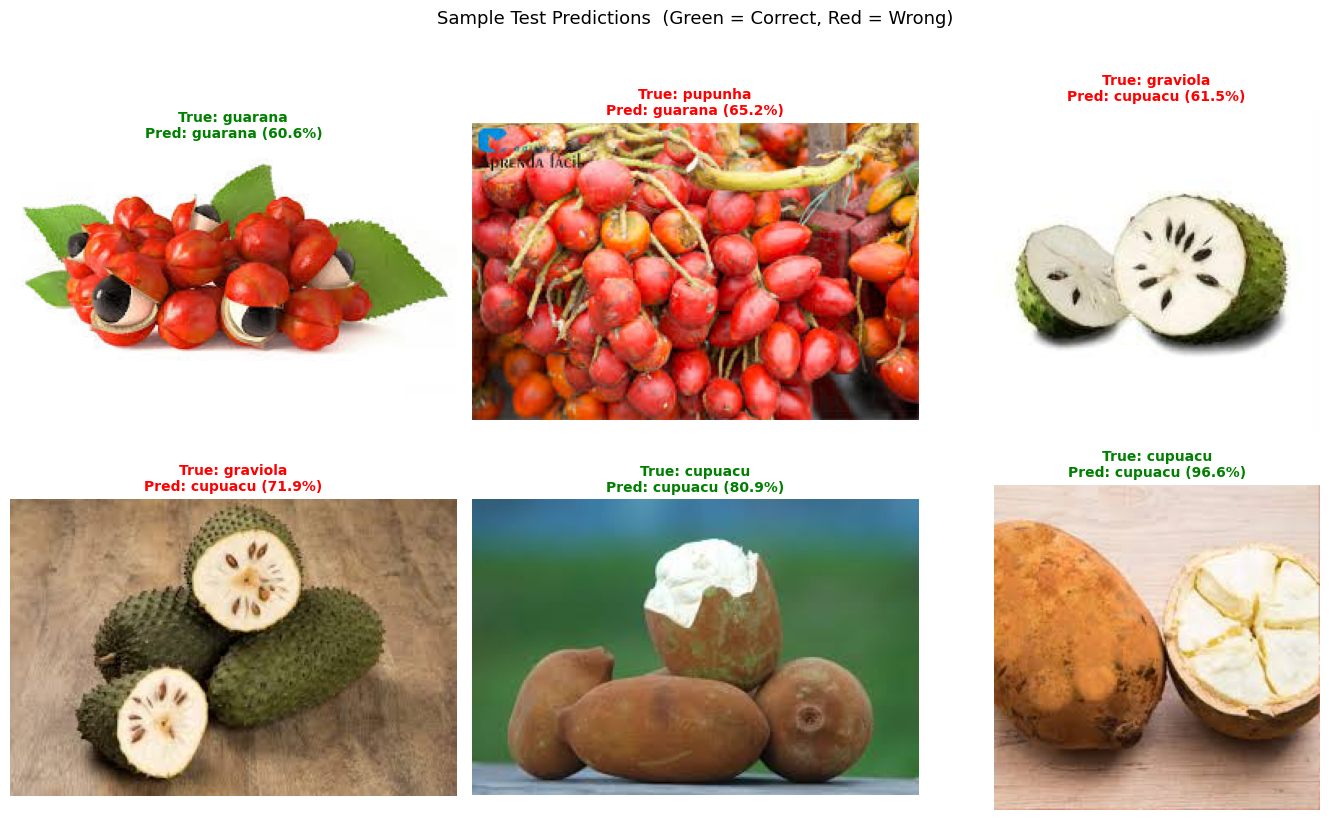

In [ ]:
#  Sample Predictions on Test Images Visualization
test_image_paths = []
test_true_labels = []

for cls in sorted(os.listdir(TEST_DIR)):
    cls_path = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            test_image_paths.append(os.path.join(cls_path, fname))
            test_true_labels.append(cls)

# Pick 6 random test images for display
sample_idx = random.sample(range(len(test_image_paths)), 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for plot_idx, img_idx in enumerate(sample_idx):
    img_path = test_image_paths[img_idx]
    true_label = test_true_labels[img_idx]

    # Preprocess for model
    img_tensor = tf.keras.utils.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img_tensor) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred_probs = loaded_model.predict(img_array, verbose=0)
    pred_label = class_names[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100

    color = "green" if pred_label == true_label else "red"
    axes[plot_idx].imshow(mpimg.imread(img_path))
    axes[plot_idx].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        fontsize=10,
        color=color,
        fontweight="bold",
    )
    axes[plot_idx].axis("off")

plt.suptitle(
    "Sample Test Predictions  (Green = Correct, Red = Wrong)", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()
